# Imports

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from neuralhydrology.nh_run import start_run, eval_run
import pickle

# Dynamic Mode

## Original dCFE

In [2]:
# Start run begins a training run on the input configuration.
path_to_config = "2basinTest_dynamic.yml"
start_run(config_file= Path(path_to_config), gpu=-1) # We are just running on CPU, so -1.

2026-04-01 13:57:33,033: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/DevMultiBasin_Test_Dynamic_0104_135733/output.log initialized.
2026-04-01 13:57:33,034: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/DevMultiBasin_Test_Dynamic_0104_135733
2026-04-01 13:57:33,034: ### Run configurations for DevMultiBasin_Test_Dynamic
2026-04-01 13:57:33,034: experiment_name: DevMultiBasin_Test_Dynamic
2026-04-01 13:57:33,035: train_basin_file: 2_basin.txt
2026-04-01 13:57:33,035: validation_basin_file: 2_basin.txt
2026-04-01 13:57:33,036: test_basin_file: 2_basin.txt
2026-04-01 13:57:33,036: train_start_date: 2000-10-01 00:00:00
2026-04-01 13:57:33,037: train_end_date: 2014-09-30 00:00:00
2026-04-01 13:57:33,037: validation_start_date: 1990-10-01 00:00:00
20

In [4]:
dcfe_run_dir_dynamic = "runs/DevMultiBasin_Test_Dynamic_0104_135733/" # Modify this to your specific run path!
eval_run(run_dir=Path(dcfe_run_dir_dynamic), period="test", gpu=-1)

2026-04-01 16:16:21,427: Using the model weights from runs/DevMultiBasin_Test_Dynamic_0104_135733/model_epoch004.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:13<00:00,  6.69s/it]

Removing overlapping predictions for hybrid model with predict_last_n > 1 on test period.
Collapses the results to generate a single continuous time series, consolidating data.

Removing overlapping internal_states and parameters for hybrid model with predict_last_n > 1 on test period.
Collapses the spin-up and prediction states/parameters into single continuous time series, consolidating data.

2026-04-01 16:16:34,855: Stored metrics at runs/DevMultiBasin_Test_Dynamic_0104_135733/test/model_epoch004/test_metrics.csv
2026-04-01 16:16:34,863: Stored results at runs/DevMultiBasin_Test_Dynamic_0104_135733/test/model_epoch004/test_results.p
2026-04-01 16:16:34,872: Stored states at runs/DevMultiBasin_Test_Dynamic_0104_135

## Snow-dCFE

In [2]:
# Start run begins a training run on the input configuration.
path_to_config = "2basin_snow_dynamic.yml"
start_run(config_file= Path(path_to_config), gpu=-1) # We are just running on CPU, so -1.

2026-04-01 16:10:17,921: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/Test_Snow_dCFE_Dynamic_0104_161017/output.log initialized.
2026-04-01 16:10:17,922: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/Test_Snow_dCFE_Dynamic_0104_161017
2026-04-01 16:10:17,922: ### Run configurations for Test_Snow_dCFE_Dynamic
2026-04-01 16:10:17,923: experiment_name: Test_Snow_dCFE_Dynamic
2026-04-01 16:10:17,923: train_basin_file: 2_basin.txt
2026-04-01 16:10:17,924: validation_basin_file: 2_basin.txt
2026-04-01 16:10:17,924: test_basin_file: 2_basin.txt
2026-04-01 16:10:17,925: train_start_date: 2000-10-01 00:00:00
2026-04-01 16:10:17,926: train_end_date: 2014-09-30 00:00:00
2026-04-01 16:10:17,926: validation_start_date: 1990-10-01 00:00:00
2026-04-01 16:10:1

In [5]:
snow_dcfe_run_dir_dynamic = "runs/Test_Snow_dCFE_Dynamic_0104_161017/" # Modify this to your specific run path!
eval_run(run_dir=Path(snow_dcfe_run_dir_dynamic), period="test", gpu=-1)

2026-04-01 16:16:54,592: Using the model weights from runs/Test_Snow_dCFE_Dynamic_0104_161017/model_epoch004.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:14<00:00,  7.43s/it]

Removing overlapping predictions for hybrid model with predict_last_n > 1 on test period.
Collapses the results to generate a single continuous time series, consolidating data.

Removing overlapping internal_states and parameters for hybrid model with predict_last_n > 1 on test period.
Collapses the spin-up and prediction states/parameters into single continuous time series, consolidating data.

2026-04-01 16:17:09,466: Stored metrics at runs/Test_Snow_dCFE_Dynamic_0104_161017/test/model_epoch004/test_metrics.csv
2026-04-01 16:17:09,468: Stored results at runs/Test_Snow_dCFE_Dynamic_0104_161017/test/model_epoch004/test_results.p
2026-04-01 16:17:09,474: Stored states at runs/Test_Snow_dCFE_Dynamic_0104_161017/test/model_e

# Visualize
## Retrieving the data
* Streamflow Predictions are stored in `test_results.p`
* Conceptual Parameters and Internal States are stored in `test_all_output.p`

In [6]:
basin = '02177000' # Modify to '02349900' if you'd like to see the results for that basin.
with open(Path(dcfe_run_dir_dynamic) / "test" / "model_epoch004" / "test_results.p", "rb") as fp:
    dynamic_dcfe_predictions = pickle.load(fp)
with open(Path(snow_dcfe_run_dir_dynamic) / "test" / "model_epoch004" / "test_results.p", "rb") as fp:
    dynamic_snow_dcfe_predictions = pickle.load(fp)

    

with open(Path(dcfe_run_dir_dynamic) / "test" / "model_epoch004" / "test_all_output.p", "rb") as fp:
    dynamic_dcfe_all_output = pickle.load(fp)
with open(Path(snow_dcfe_run_dir_dynamic) / "test" / "model_epoch004" / "test_all_output.p", "rb") as fp:
    dynamic_snow_dcfe_all_output = pickle.load(fp)

    
# keys of prediction modes
prediction_mode_keys = ["Dynamic","Oracle Averaging","Operational Averaging"]
# grab keys of parmeters and internal states
dcfe_param_keys = list(dynamic_dcfe_all_output[basin]["spinup_parameters"].keys())
dcfe_state_keys = list(dynamic_dcfe_all_output[basin]["spinup_internal_states"].keys())

snow_dcfe_param_keys = list(dynamic_snow_dcfe_all_output[basin]["spinup_parameters"].keys())
snow_dcfe_state_keys = list(dynamic_snow_dcfe_all_output[basin]["spinup_internal_states"].keys())

## Plotting Predictions For Both Models

In [9]:
from neuralhydrology.evaluation.metrics import nse

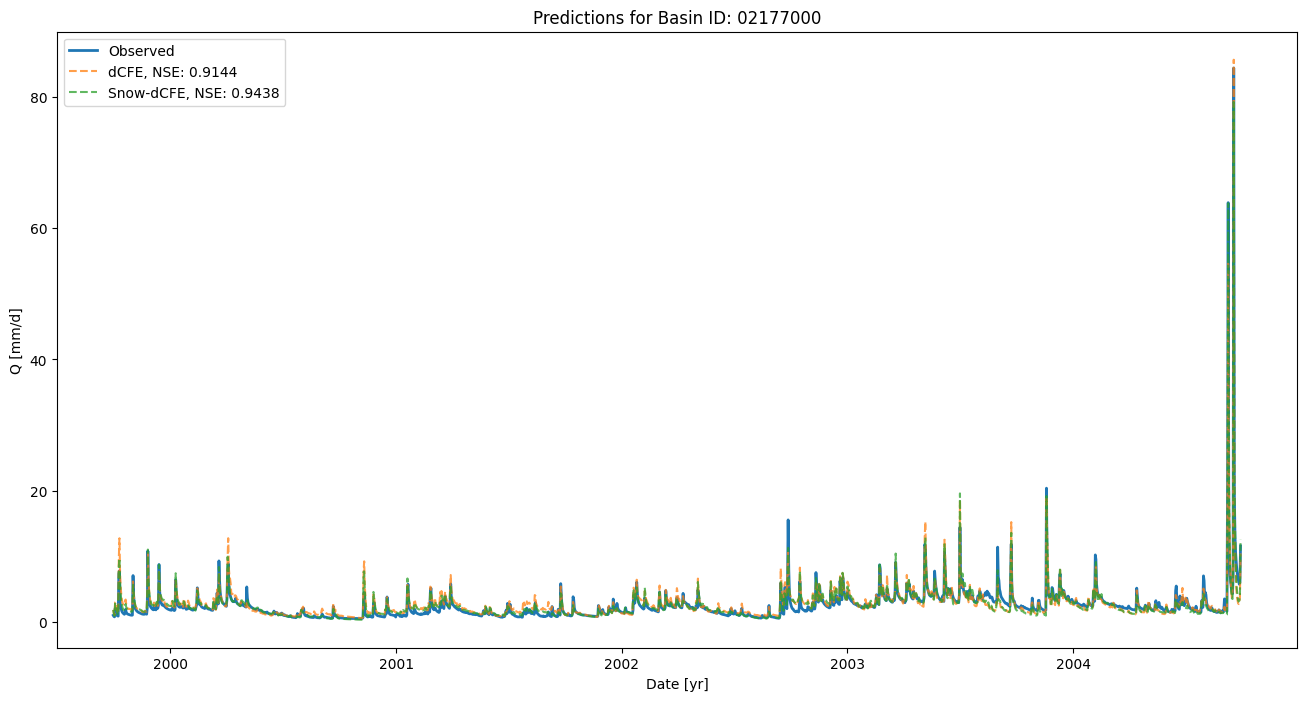

In [17]:
fig, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1)
dates = dynamic_dcfe_predictions[basin]["1D"]["xr"]["datetime"]
observed = dynamic_dcfe_predictions[basin]["1D"]["xr"]["QObs(mm/d)_obs"]

dcfe_simulated = dynamic_dcfe_predictions[basin]["1D"]["xr"]["QObs(mm/d)_sim"]
snow_dcfe_simulated = dynamic_snow_dcfe_predictions[basin]["1D"]["xr"]["QObs(mm/d)_sim"]
nse_dcfe = nse(observed, dcfe_simulated)
nse_snow_dcfe = nse(observed, snow_dcfe_simulated)

ax.plot(dates,
        observed,
        label="Observed",
        linewidth=2)

ax.plot(dates,
        dcfe_simulated,
        label=f"dCFE, NSE: {nse_dcfe:.4f}",
        linestyle="--",
        alpha=0.75)

ax.plot(dates,
        snow_dcfe_simulated,
        label=f"Snow-dCFE, NSE: {nse_snow_dcfe:.4f}",
        linestyle="--",
        alpha=0.75)   


ax.set_ylabel("Q [mm/d]")
ax.set_xlabel("Date [yr]")
ax.set_title(f"Predictions for Basin ID: {basin}")
ax.legend()

## Plotting SHM Conceptual Parameters For All Modes

In [19]:
len(snow_dcfe_param_keys)

11

In [20]:
snow_dcfe_param_keys

['satdk',
 'Cgw',
 'bb',
 'smcmax',
 'slop',
 'max_gw_storage',
 'expon',
 'K_lf',
 'K_nash',
 'satpsi',
 'dd']

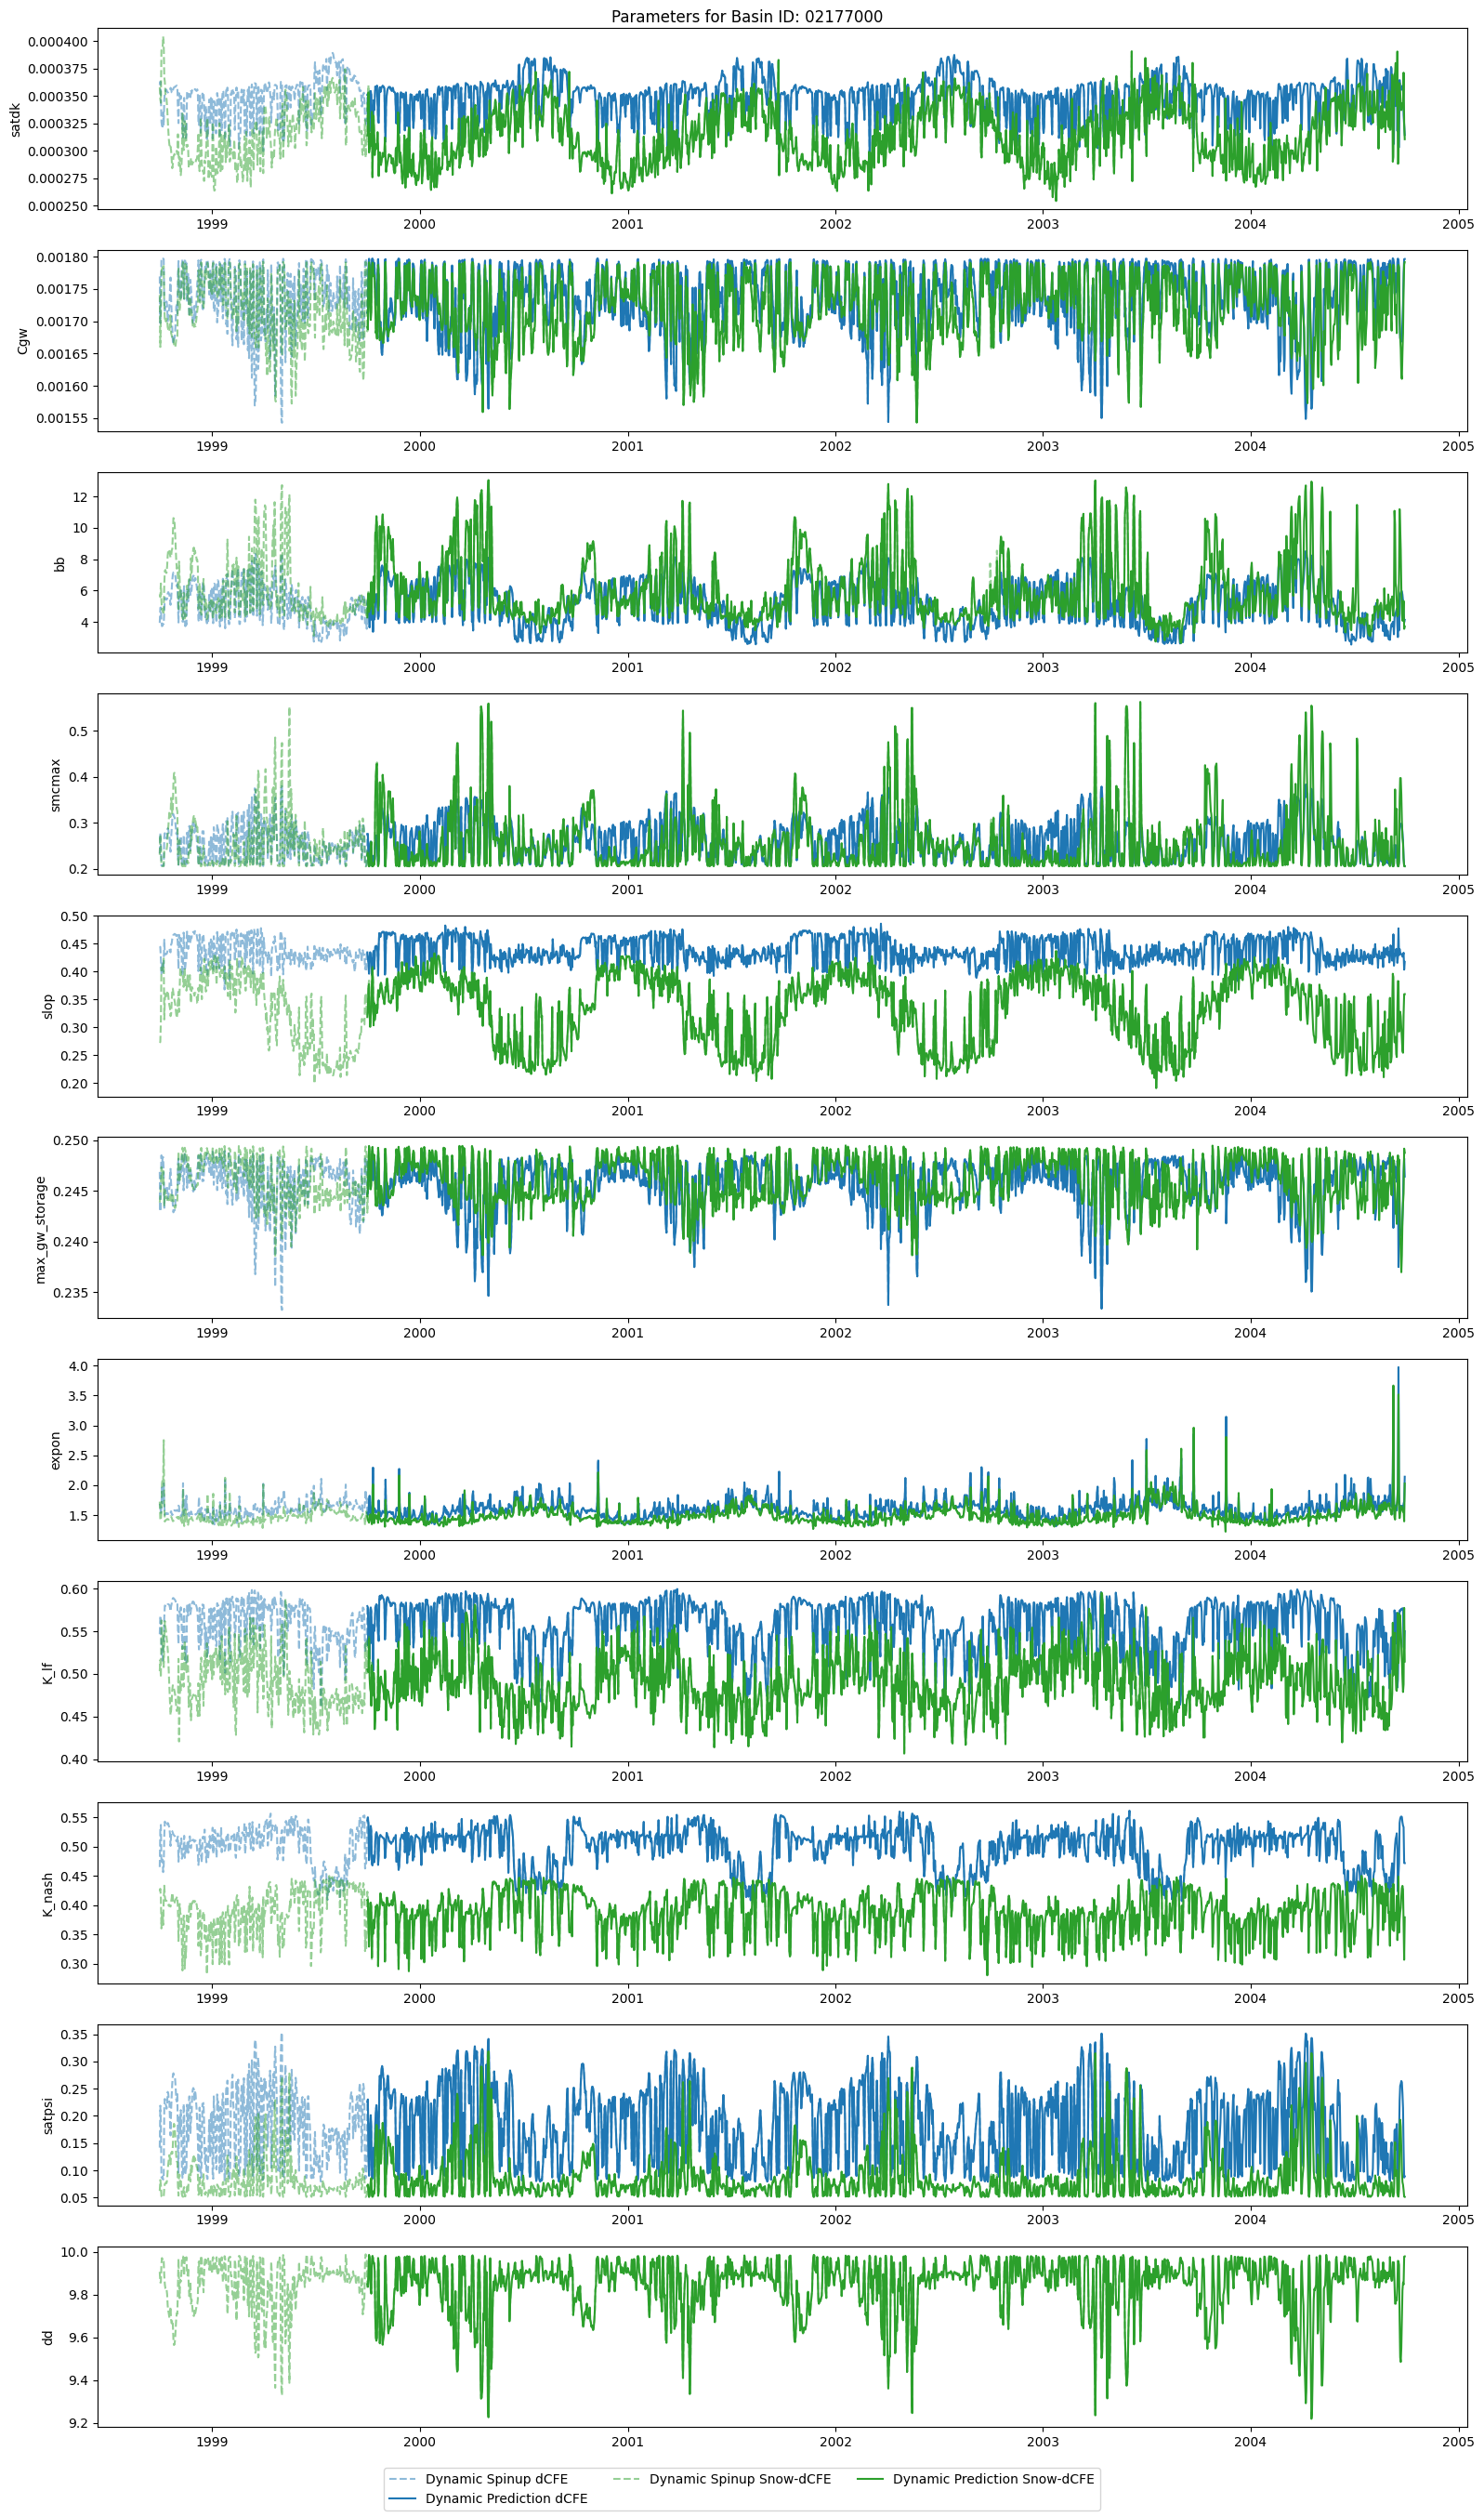

In [23]:
param_dates = dynamic_dcfe_all_output['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(snow_dcfe_param_keys)), nrows=len(snow_dcfe_param_keys), ncols=1)
for i, param_interest in enumerate(dcfe_param_keys):
    label_dynamic_dcfe_spinup = "Dynamic Spinup dCFE" if i == 0 else None
    label_dynamic_dcfe_prediction = "Dynamic Prediction dCFE" if i == 0 else None
    label_dynamic_snow_dcfe_spinup = "Dynamic Spinup Snow-dCFE" if i == 0 else None
    label_dynamic_snow_dcfe_prediction = "Dynamic Prediction Snow-dCFE" if i == 0 else None
    ax[i].plot(param_dates, dynamic_dcfe_all_output[basin]["spinup_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_dcfe_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, dynamic_dcfe_all_output[basin]["prediction_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_dcfe_prediction, linestyle='-')
    ax[i].plot(param_dates, dynamic_snow_dcfe_all_output[basin]["spinup_parameters"][param_interest],
               color="tab:green", label=label_dynamic_snow_dcfe_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, dynamic_snow_dcfe_all_output[basin]["prediction_parameters"][param_interest],
               color="tab:green", label=label_dynamic_snow_dcfe_prediction, linestyle='-')
    ax[i].set_ylabel(f"{param_interest}")
i = len(snow_dcfe_param_keys) - 1
param_interest = snow_dcfe_param_keys[i]
ax[i].plot(param_dates, dynamic_snow_dcfe_all_output[basin]["spinup_parameters"][param_interest],
               color="tab:green", label=label_dynamic_snow_dcfe_spinup, linestyle='--', alpha = 0.5)
ax[i].plot(param_dates, dynamic_snow_dcfe_all_output[basin]["prediction_parameters"][param_interest],
               color="tab:green", label=label_dynamic_snow_dcfe_prediction, linestyle='-')
ax[i].set_ylabel(f"{param_interest}")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"Parameters for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

## Plotting Internal States

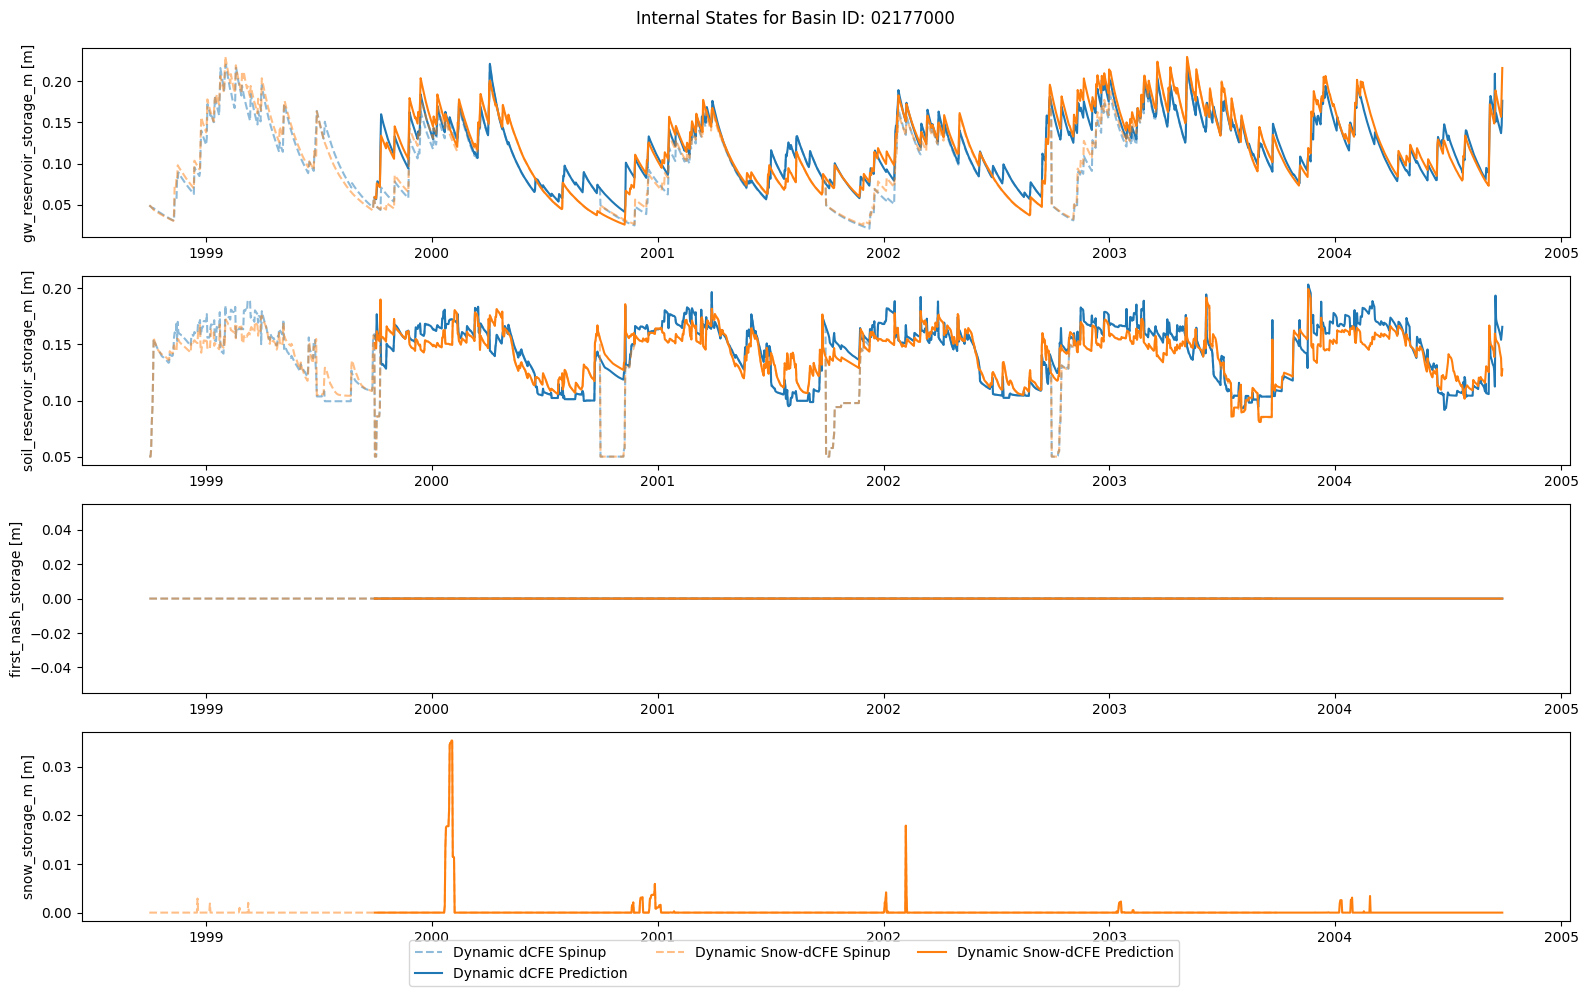

In [25]:
state_dates = dynamic_dcfe_all_output['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(snow_dcfe_state_keys)), nrows=len(snow_dcfe_state_keys), ncols=1)
for i, state_interest in enumerate(dcfe_state_keys):
    label_dynamic_dcfe_spinup = "Dynamic dCFE Spinup" if i == 0 else None
    label_dynamic_dcfe_prediction = "Dynamic dCFE Prediction" if i == 0 else None
    label_dynamic_snow_dcfe_spinup = "Dynamic Snow-dCFE Spinup" if i == 0 else None
    label_dynamic_snow_dcfe_prediction = "Dynamic Snow-dCFE Prediction" if i == 0 else None
    ax[i].plot(state_dates, dynamic_dcfe_all_output[basin]["spinup_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_dcfe_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(state_dates, dynamic_dcfe_all_output[basin]["prediction_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_dcfe_prediction, linestyle='-')
    ax[i].plot(state_dates, dynamic_snow_dcfe_all_output[basin]["spinup_internal_states"][state_interest],
               color="tab:orange", label=label_dynamic_snow_dcfe_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(state_dates, dynamic_snow_dcfe_all_output[basin]["prediction_internal_states"][state_interest],
               color="tab:orange", label=label_dynamic_snow_dcfe_prediction, linestyle='-')
    ax[i].set_ylabel(f"{state_interest} [m]")
i = len(snow_dcfe_state_keys) - 1
state_interest = snow_dcfe_state_keys[i]
ax[i].plot(state_dates, dynamic_snow_dcfe_all_output[basin]["spinup_internal_states"][state_interest],
                color="tab:orange", label=label_dynamic_snow_dcfe_spinup, linestyle='--', alpha = 0.5)
ax[i].plot(state_dates, dynamic_snow_dcfe_all_output[basin]["prediction_internal_states"][state_interest],
                color="tab:orange", label=label_dynamic_snow_dcfe_prediction, linestyle='-')
ax[i].set_ylabel(f"{state_interest} [m]")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"Internal States for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.03, 1, 0.99])